**Importing pandas library**

In [1]:
import pandas as pd

**Loading dataset**

In [10]:
df = pd.read_csv("../data/raw/used_car_price_dataset.csv")

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1996,15.25,1500,Petrol,2,5498.71,Hyundai,Manual,Silver,NaN,0,Yes
9996,1997,14.45,5000,Diesel,1,9588.31,Honda,Manual,Gray,Full,0,Yes
9997,2002,19.41,1000,Diesel,4,4557.10,Kia,Manual,Black,Full,0,Yes
9998,2005,12.95,4000,Petrol,5,7413.59,BMW,Automatic,Blue,Full,0,Yes


**EDA activities - exploring and investigating data**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [12]:
df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [16]:
df.shape

(10000, 12)

In [13]:
df.isnull().sum()

make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

In [18]:
df.isnull().sum()/len(df)*100

make_year              0.00
mileage_kmpl           0.00
engine_cc              0.00
fuel_type              0.00
owner_count            0.00
price_usd              0.00
brand                  0.00
transmission           0.00
color                  0.00
service_history       20.38
accidents_reported     0.00
insurance_valid        0.00
dtype: float64

In [20]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

**Outlier identifying (z score, IQR)**

In [28]:
def zscores(col):
    z = ((df[col]-df[col].mean())/df[col].std()).abs()
    outlier = (z>3).sum()
    return outlier

def IQR_method(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = ((df[col]<lower) | (df[col]>upper)).sum()
    return outlier

col_list = [x for x in df.columns if df[x].dtype in ["int64", "float64"] and x!="price_usd"]

for col in col_list:
    zscore = zscores(col)
    IQR = IQR_method(col)
    print(f"Column: {col} | Z-score: {zscore}, IQR: {IQR}")


Column: make_year | Z-score: 0, IQR: 0
Column: mileage_kmpl | Z-score: 11, IQR: 36
Column: engine_cc | Z-score: 0, IQR: 0
Column: owner_count | Z-score: 0, IQR: 0
Column: accidents_reported | Z-score: 130, IQR: 130


**Data Visualization**

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

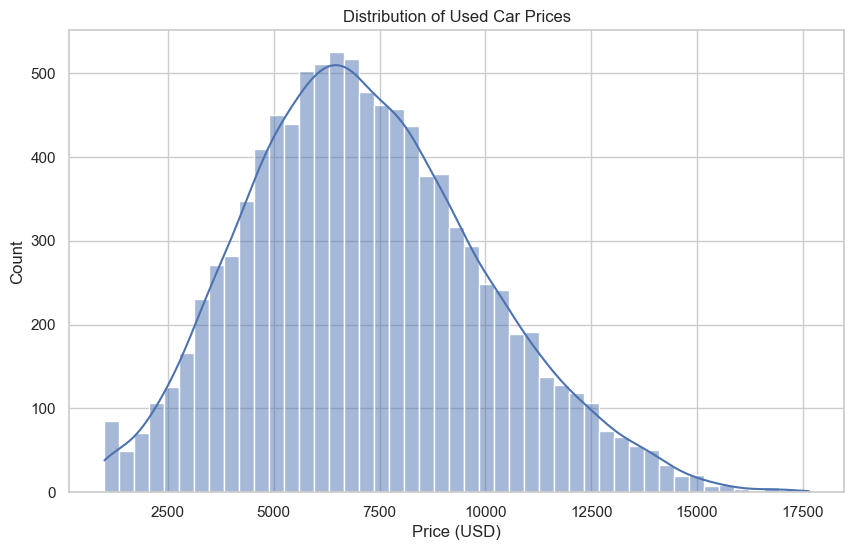

In [38]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['price_usd'], kde=True) 
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

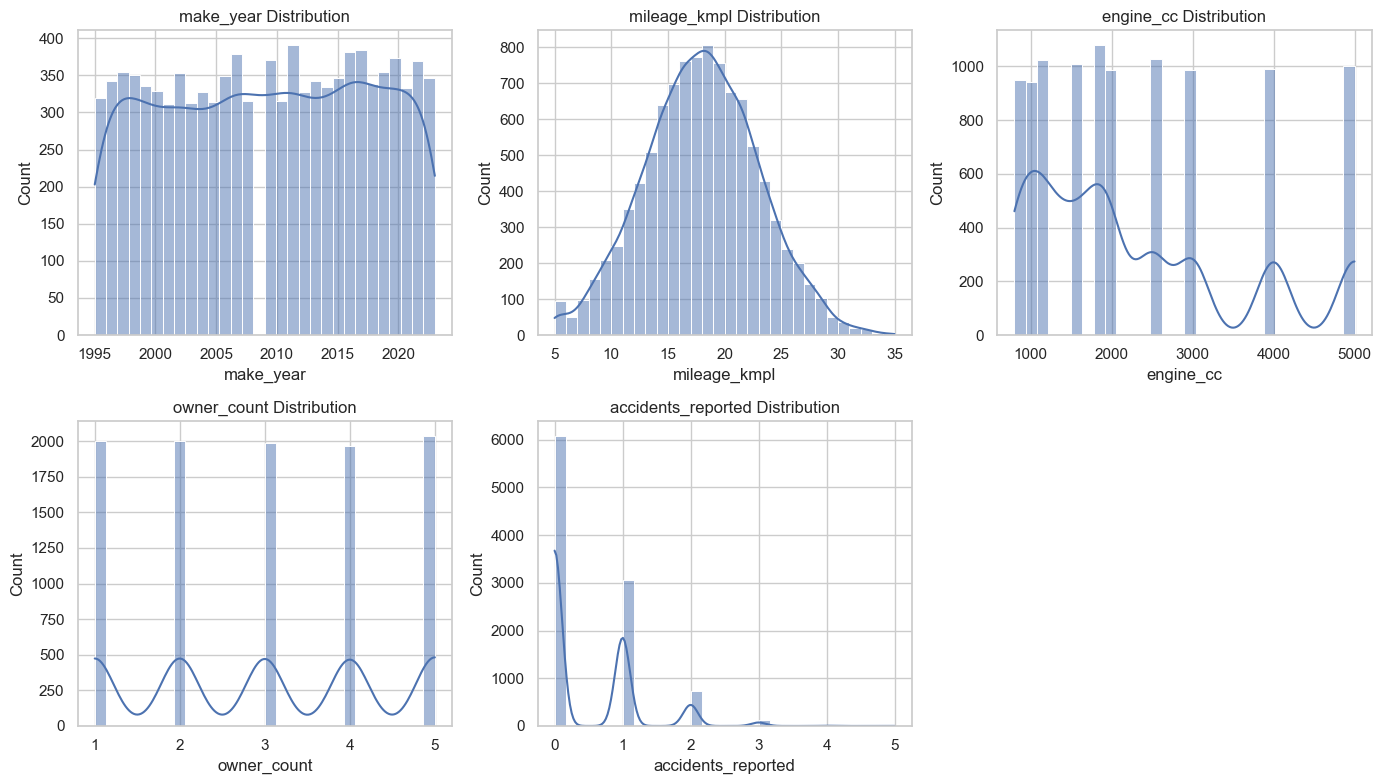

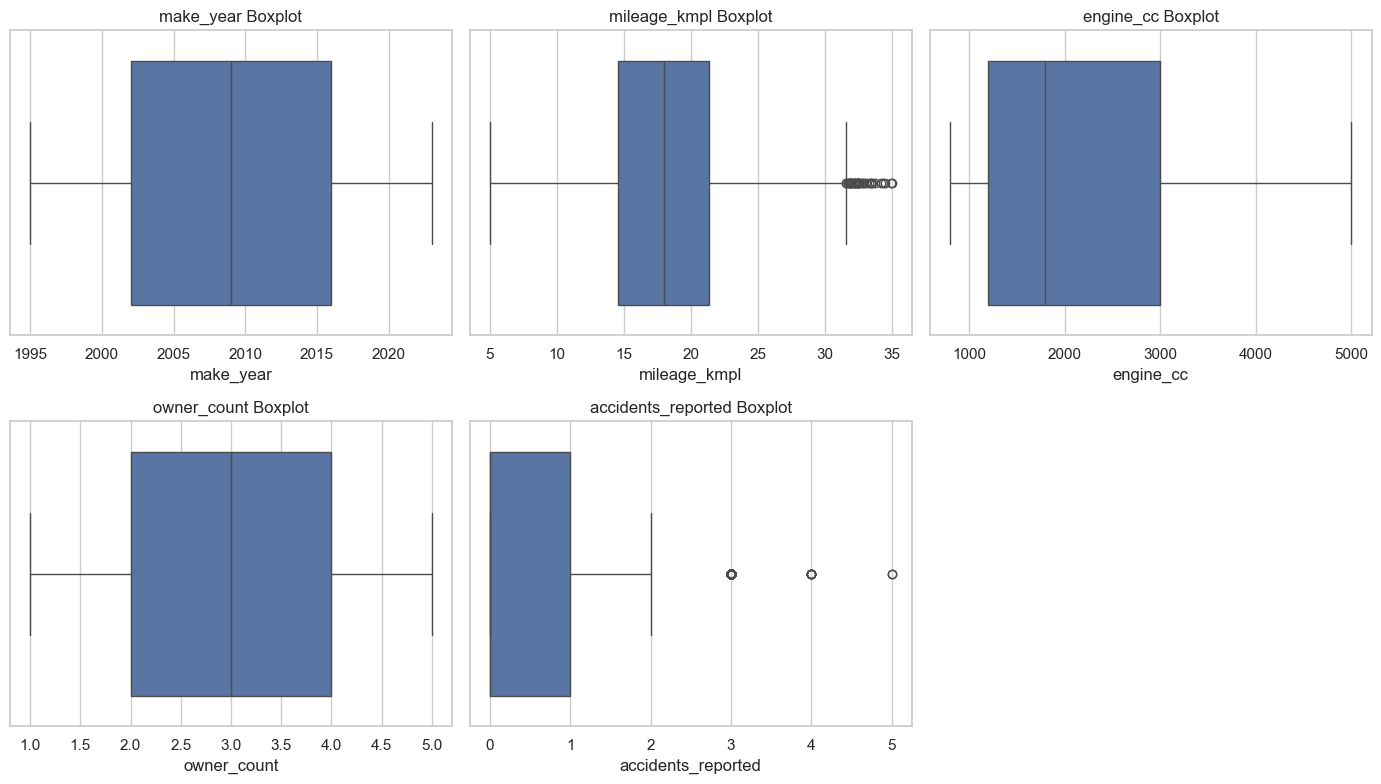

In [48]:
numeric_cols = [x for x in df.columns if df[x].dtype in ["int64", "float64"] and x!="price_usd"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()



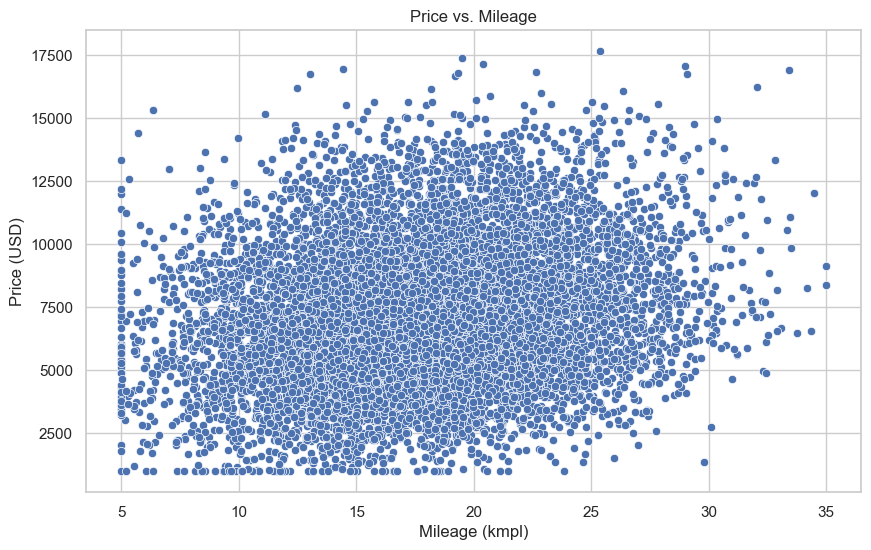

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['mileage_kmpl'], y=df['price_usd'])
plt.title('Price vs. Mileage')
plt.xlabel('Mileage (kmpl)')
plt.ylabel('Price (USD)')
plt.show()

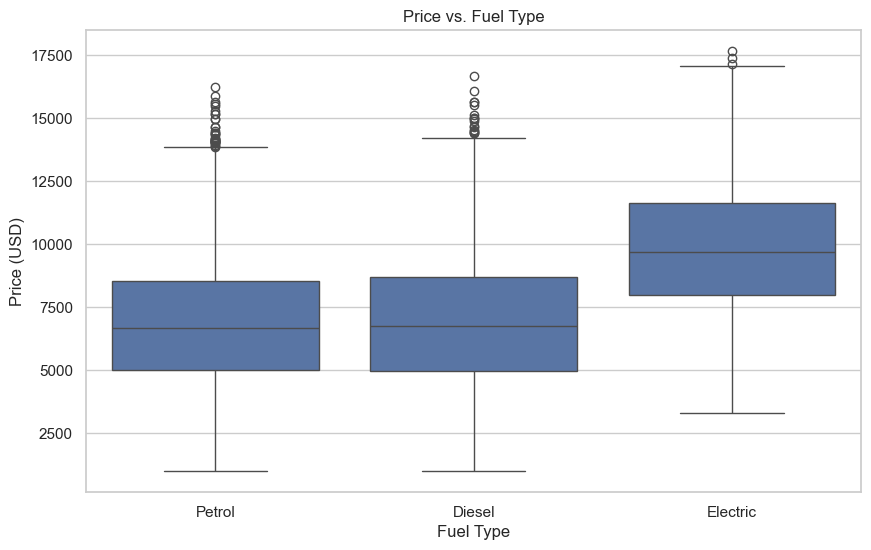

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['fuel_type'], y=df['price_usd'])
plt.title('Price vs. Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price (USD)')
plt.show()

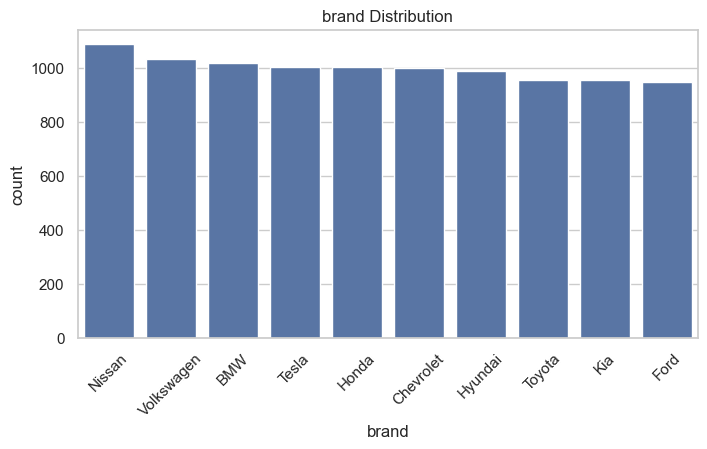

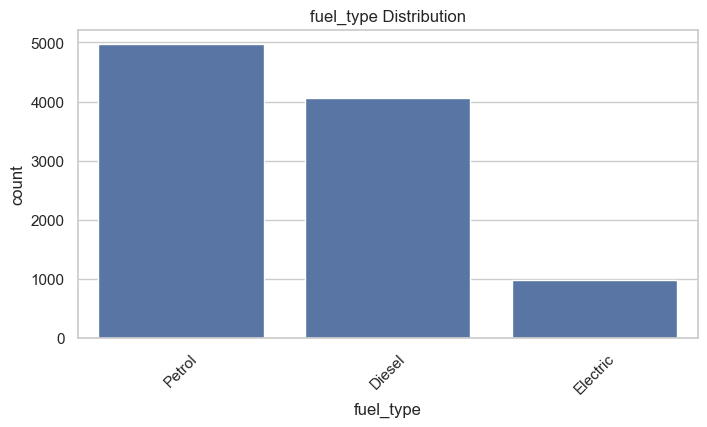

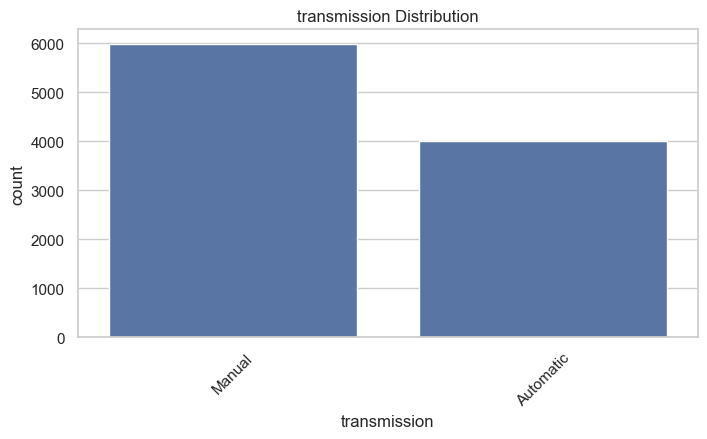

In [51]:
for col in ['brand', 'fuel_type', 'transmission']:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()


**Skew, Kurtosis and Correlation matrix**

In [52]:
df[numeric_cols].skew()
df[numeric_cols].kurt()


make_year            -1.206060
mileage_kmpl         -0.123947
engine_cc            -0.400853
owner_count          -1.307055
accidents_reported    1.793889
dtype: float64

In [55]:
corr_mat = df.corr(numeric_only = True)
corr_mat

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
make_year,1.000000,-0.013167,-0.017912,-0.021550,0.432603,-0.005151
mileage_kmpl,-0.013167,1.000000,-0.003222,-0.008310,0.211971,0.004567
engine_cc,-0.017912,-0.003222,1.000000,-0.000358,0.678161,-0.007750
owner_count,-0.021550,-0.008310,-0.000358,1.000000,-0.262266,-0.009365
price_usd,0.432603,0.211971,0.678161,-0.262266,1.000000,-0.001461
accidents_reported,-0.005151,0.004567,-0.007750,-0.009365,-0.001461,1.000000
